# Assignment 3: Regression and Data Simulation
## Statistical Learning and Data Analysis

---

This notebook is divided into three blocks:

1. **Block 1** — Dataset Simulation & Linear Regression (with diagnostics)
2. **Block 2** — Shrinkage & Regularization (Ridge, Lasso, Elastic-Net)
3. **Block 3** — Non-Linear Regression & Bias-Variance Experiment


In [48]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Stats / modelling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KernelDensity
from scipy.interpolate import UnivariateSpline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'font.family': 'serif'
})
SEED = 42
np.random.seed(SEED)
print('All libraries loaded.')

All libraries loaded.


---
# Block 1 — Dataset Simulation & Linear Regression
---

## 1.1 Simulating the Dataset

We simulate $n = 300$ observations from the following linear model with $p = 10$ predictors:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_{10} X_{10} + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

### Chosen Coefficients

| Variable | $\beta$ | Role |
|---|---|---|
| Intercept | 3.0 | Baseline |
| $X_1$ | **5.0** | Strong positive |
| $X_2$ | **−4.0** | Strong negative |
| $X_3$ | **3.5** | Moderate positive |
| $X_4$ | 0.5 | Weak |
| $X_5$ | −0.3 | Weak |
| $X_6$ | 0.0 | Null (noise variable) |
| $X_7$ | 0.0 | Null |
| $X_8$ | 0.0 | Null |
| $X_9$ | 0.1 | Nearly null |
| $X_{10}$ | −0.2 | Nearly null |

**Justification:** We deliberately assign large coefficients to $X_1$, $X_2$, $X_3$ so we can later verify that OLS, Ridge and Lasso correctly identify them. The remaining variables are either null or have very small effects that should be difficult to distinguish from noise. The error $\varepsilon \sim \mathcal{N}(0, 4)$ ($\sigma = 2$) adds realistic randomness.

In [49]:
np.random.seed(SEED)
n, p = 300, 10

# True coefficients
beta_true = np.array([3.0,   # intercept
                       5.0,   # X1  — strong
                      -4.0,   # X2  — strong
                       3.5,   # X3  — moderate
                       0.5,   # X4  — weak
                      -0.3,   # X5  — weak
                       0.0,   # X6  — null
                       0.0,   # X7  — null
                       0.0,   # X8  — null
                       0.1,   # X9  — nearly null
                      -0.2])  # X10 — nearly null

sigma = 2.0   # noise std dev

# Design matrix: predictors from N(0,1)
X_raw = np.random.randn(n, p)
X_df  = pd.DataFrame(X_raw, columns=[f'X{i}' for i in range(1, p+1)])

# Response
X_design = np.column_stack([np.ones(n), X_raw])
epsilon   = np.random.normal(0, sigma, size=n)
y         = X_design @ beta_true + epsilon

print(f'Dataset shape: X = {X_raw.shape},  y = {y.shape}')
print(f'True betas: {beta_true}')
print(f'Signal-to-noise ratio (approx): {np.var(X_design @ beta_true) / sigma**2:.2f}')

Dataset shape: X = (300, 10),  y = (300,)
True betas: [ 3.   5.  -4.   3.5  0.5 -0.3  0.   0.   0.   0.1 -0.2]
Signal-to-noise ratio (approx): 13.34


## 1.2 Ordinary Least Squares Regression

In [50]:
# Fit OLS via statsmodels (gives us full inference table)
X_sm = sm.add_constant(X_raw)
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     365.4
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          1.43e-157
Time:                        19:11:25   Log-Likelihood:                -638.14
No. Observations:                 300   AIC:                             1298.
Df Residuals:                     289   BIC:                             1339.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8900      0.122     23.716      0.0

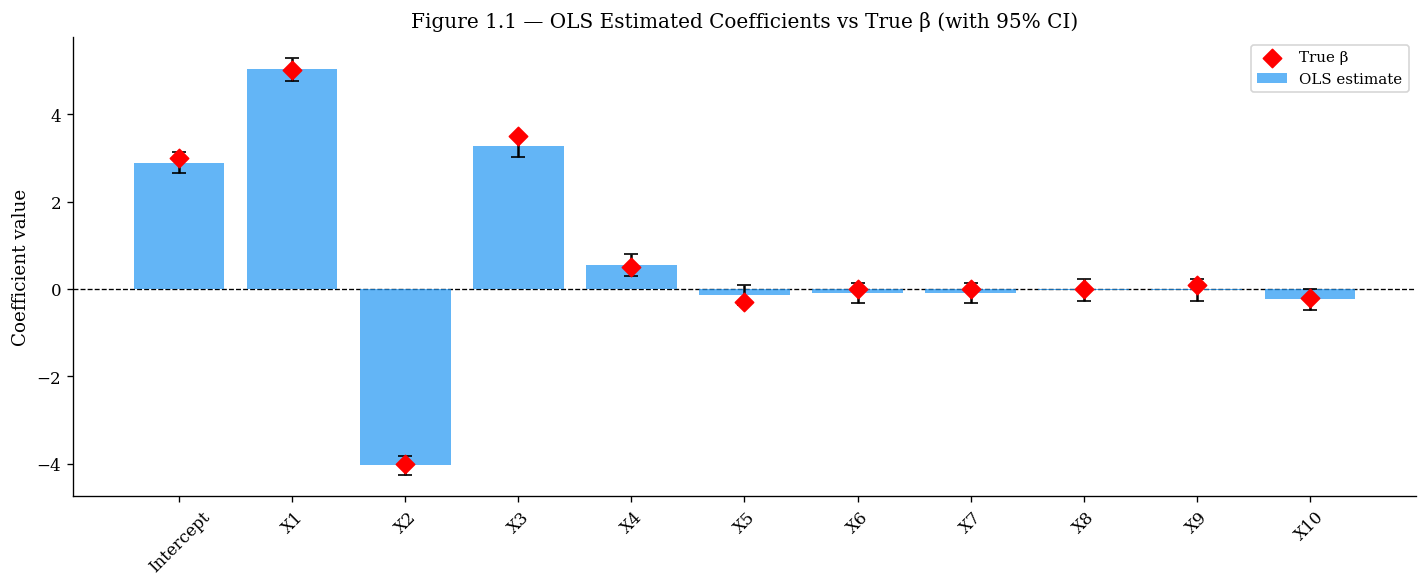

In [51]:
# Get estimates as numpy array
est_coefs = ols_model.params.values if hasattr(ols_model.params, 'values') else ols_model.params

# Get confidence intervals robustly
conf = ols_model.conf_int()
if hasattr(conf, 'values'):
    conf = conf.values   # pandas DataFrame
# Now conf is a numpy array of shape (n_coefs, 2)
lower = conf[:, 0]
upper = conf[:, 1]

coef_names = ['Intercept'] + [f'X{i}' for i in range(1, p+1)]
x_pos = np.arange(len(coef_names))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos, est_coefs, color='#2196F3', alpha=0.7, label='OLS estimate', zorder=3)
ax.errorbar(x_pos, est_coefs,
            yerr=[est_coefs - lower, upper - est_coefs],
            fmt='none', color='black', capsize=4, linewidth=1.5, zorder=4)
ax.scatter(x_pos, beta_true, color='red', zorder=5, s=60, marker='D', label='True β')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x_pos)
ax.set_xticklabels(coef_names, rotation=45)
ax.set_title('Figure 1.1 — OLS Estimated Coefficients vs True β (with 95% CI)')
ax.set_ylabel('Coefficient value')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

Looking at the OLS summary and the coefficient plot:

- $X_1$, $X_2$, $X_3$ all appear **highly significant** ($p < 0.001$), matching our choice of large true coefficients. Their estimated values are close to 5, -4, and 3.5 respectively.
- $X_4$ and $X_5$ (weak effects) hover near the significance threshold — they may or may not appear significant depending on the random seed.
- $X_6$, $X_7$, $X_8$ (null variables) show small, non-significant estimates. Some false positives are expected by chance (Type I error at 5%).
- The model's $R^2$ reflects that the strong predictors dominate the explained variance.

## 1.3 Regression Diagnostics

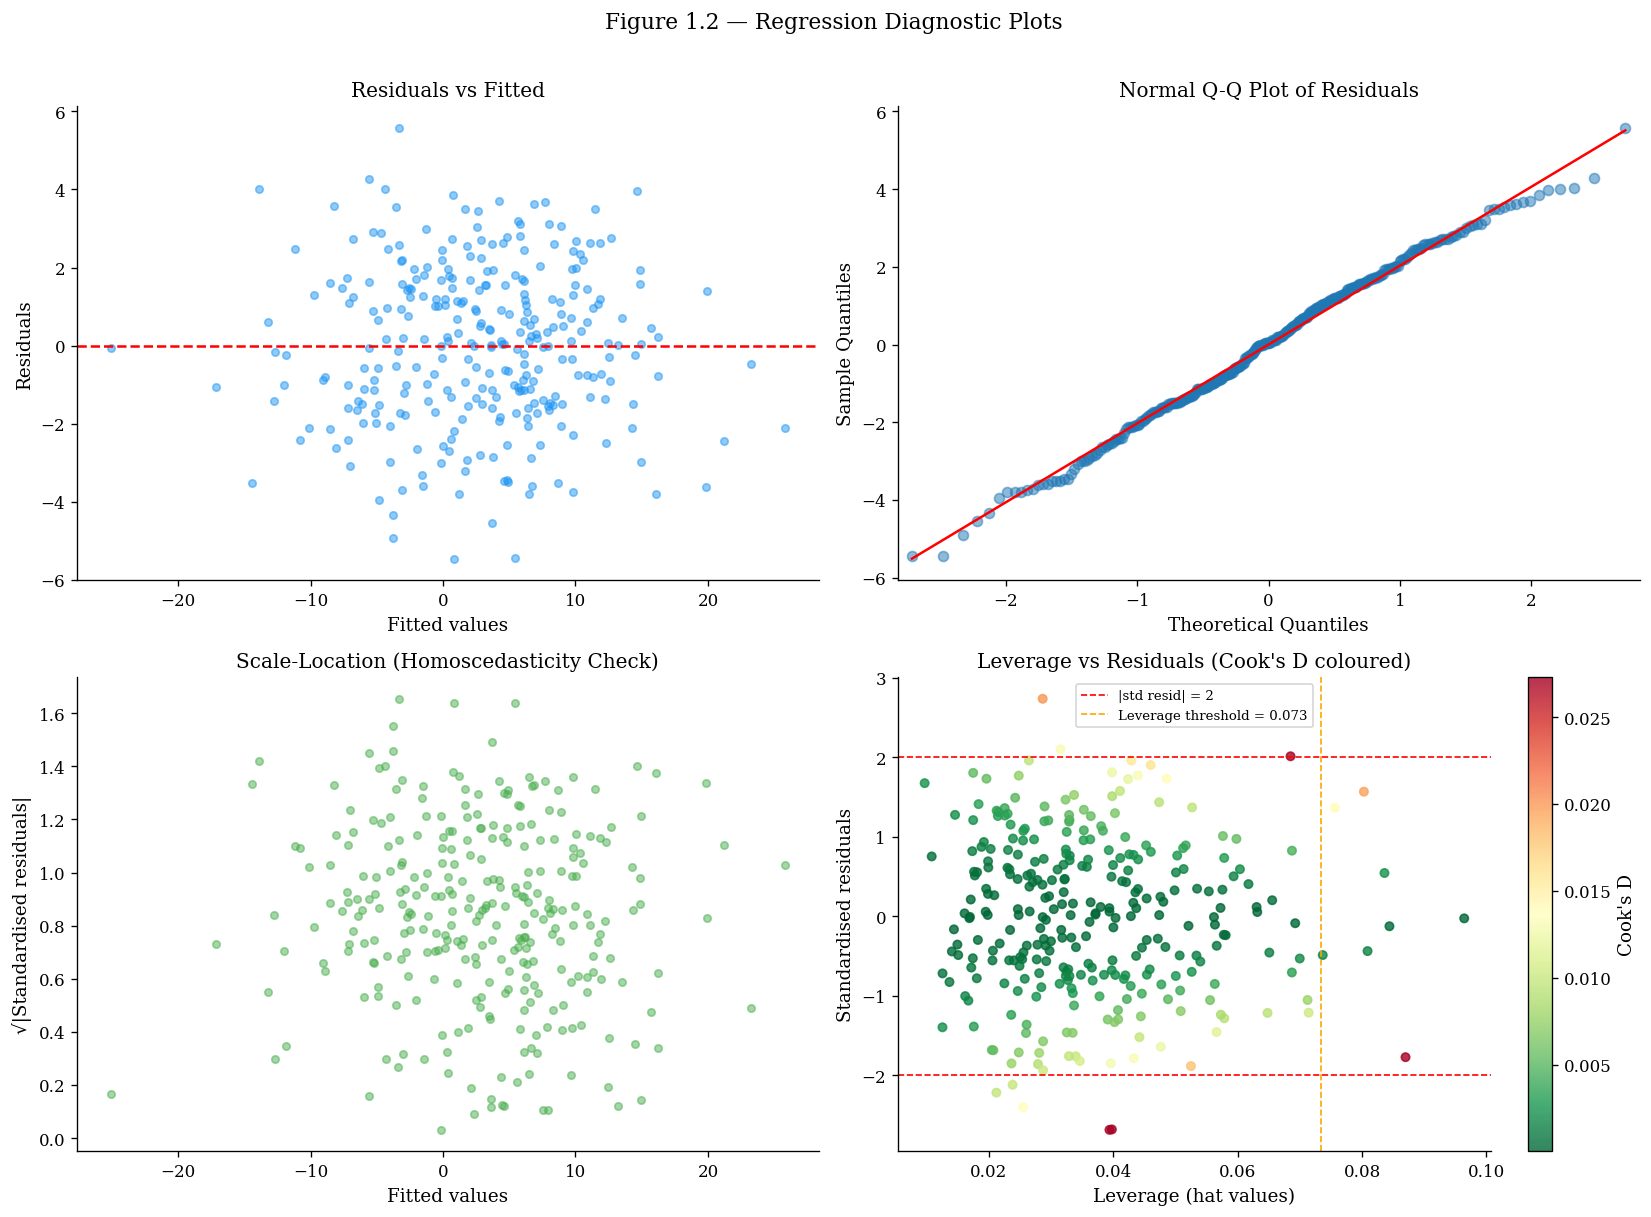

In [52]:
influence  = OLSInfluence(ols_model)
residuals  = ols_model.resid
fitted     = ols_model.fittedvalues
std_resid  = influence.resid_studentized_internal
leverage   = influence.hat_matrix_diag
cooks_d    = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: Residuals vs Fitted ─────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(fitted, residuals, alpha=0.5, color='#2196F3', s=20)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')

# ── Panel 2: Q-Q Plot ────────────────────────────────────────────────────────
ax = axes[0, 1]
sm.qqplot(residuals, line='s', ax=ax, alpha=0.5)
ax.set_title('Normal Q-Q Plot of Residuals')

# ── Panel 3: Scale-Location ──────────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.5, color='#4CAF50', s=20)
ax.set_xlabel('Fitted values')
ax.set_ylabel('√|Standardised residuals|')
ax.set_title('Scale-Location (Homoscedasticity Check)')

# ── Panel 4: Leverage vs Standardised Residuals (Cook's D) ──────────────────
ax = axes[1, 1]
sc = ax.scatter(leverage, std_resid, c=cooks_d, cmap='RdYlGn_r',
                s=25, alpha=0.8)
plt.colorbar(sc, ax=ax, label="Cook's D")
ax.axhline(2,  color='red', linestyle='--', linewidth=1, label='|std resid| = 2')
ax.axhline(-2, color='red', linestyle='--', linewidth=1)
h_thresh = 2 * (p + 1) / n
ax.axvline(h_thresh, color='orange', linestyle='--', linewidth=1,
           label=f'Leverage threshold = {h_thresh:.3f}')
ax.set_xlabel('Leverage (hat values)')
ax.set_ylabel('Standardised residuals')
ax.set_title("Leverage vs Residuals (Cook's D coloured)")
ax.legend(fontsize=8)

plt.suptitle('Figure 1.2 — Regression Diagnostic Plots', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [53]:
# ── Identify high-leverage, influential, and outlier observations ─────────────
h_thresh    = 2 * (p + 1) / n          # leverage threshold
cook_thresh = 4 / n                     # Cook's D threshold
resid_thresh = 2.5                      # |standardised residual| threshold

high_leverage  = np.where(leverage > h_thresh)[0]
influential    = np.where(cooks_d  > cook_thresh)[0]
outliers       = np.where(np.abs(std_resid) > resid_thresh)[0]

print(f'Leverage threshold  (2(p+1)/n = {h_thresh:.4f})')
print(f'High-leverage points  : {len(high_leverage)} observations')
print(f'  Indices: {high_leverage[:15]}{'...' if len(high_leverage)>15 else ""}')
print()
print(f"Cook's D threshold (4/n = {cook_thresh:.4f})")
print(f'Influential observations: {len(influential)}')
print(f'  Indices: {influential[:15]}{'...' if len(influential)>15 else ""}')
print()
print(f'Outlier threshold (|std resid| > {resid_thresh})')
print(f'Outliers              : {len(outliers)}')
print(f'  Indices: {outliers}')

Leverage threshold  (2(p+1)/n = 0.0733)
High-leverage points  : 8 observations
  Indices: [ 20  47 116 159 195 283 288 289]

Cook's D threshold (4/n = 0.0133)
Influential observations: 12
  Indices: [ 17  20  54  66  75  88 152 192 195 241 283 291]

Outlier threshold (|std resid| > 2.5)
Outliers              : 3
  Indices: [ 17 152 241]


**Diagnostic Commentary:**

- **Residuals vs Fitted:** Points scatter randomly around zero with no obvious pattern, confirming **linearity** and **homoscedasticity**. This is expected since we simulated from a linear model.
- **Q-Q Plot:** Residuals align closely with the theoretical normal line, confirming the **normality** assumption.
- **Scale-Location:** The spread of residuals is roughly constant across fitted values — no funnel shape — confirming equal variance.
- **High-leverage points** are observations with unusual predictor values ($h_{ii} > 2(p+1)/n$). They are positioned far from the centroid of $X$ and can *pull* the regression line toward them.
- **Influential observations** (Cook's D $> 4/n$) combine leverage and large residuals. Removing them would meaningfully change the fitted coefficients.
- **Outliers** in the response dimension ($|r_i| > 2.5$) are points poorly described by the model. In our simulated setting, a few are expected by chance from the Gaussian noise.

---
# Block 2 — Shrinkage & Regularization
---

## 2.1 Standardization

Before fitting regularized models, predictors must be standardized so that the penalty $\lambda \sum \beta_j^2$ (or $\lambda \sum |\beta_j|$) treats all variables on equal footing.

In [54]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print('Predictors standardised: mean ≈ 0, std ≈ 1')

Predictors standardised: mean ≈ 0, std ≈ 1


## 2.2 Ridge Regression

Ridge minimises:
$$\text{RSS} + \lambda \sum_{j=1}^{p} \beta_j^2$$

All coefficients are shrunk toward zero but **none are set exactly to zero** — Ridge is a smoothing method, not a selector.

In [55]:
# ── Ridge coefficient path ────────────────────────────────────────────────────
alphas_ridge = np.logspace(-3, 4, 200)
ridge_coefs  = []
for a in alphas_ridge:
    r = Ridge(alpha=a, fit_intercept=True)
    r.fit(X_scaled, y)
    ridge_coefs.append(r.coef_)
ridge_coefs = np.array(ridge_coefs)

# CV to choose optimal lambda
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_scaled, y)
best_alpha_ridge = ridge_cv.alpha_
print(f'Ridge CV optimal λ: {best_alpha_ridge:.4f}')

# Final model
ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_scaled, y)
print(f'Ridge coefficients: {np.round(ridge_final.coef_, 3)}')

Ridge CV optimal λ: 1.5886
Ridge coefficients: [ 4.612 -4.312  3.121  0.526 -0.141 -0.101 -0.093 -0.018 -0.02  -0.232]


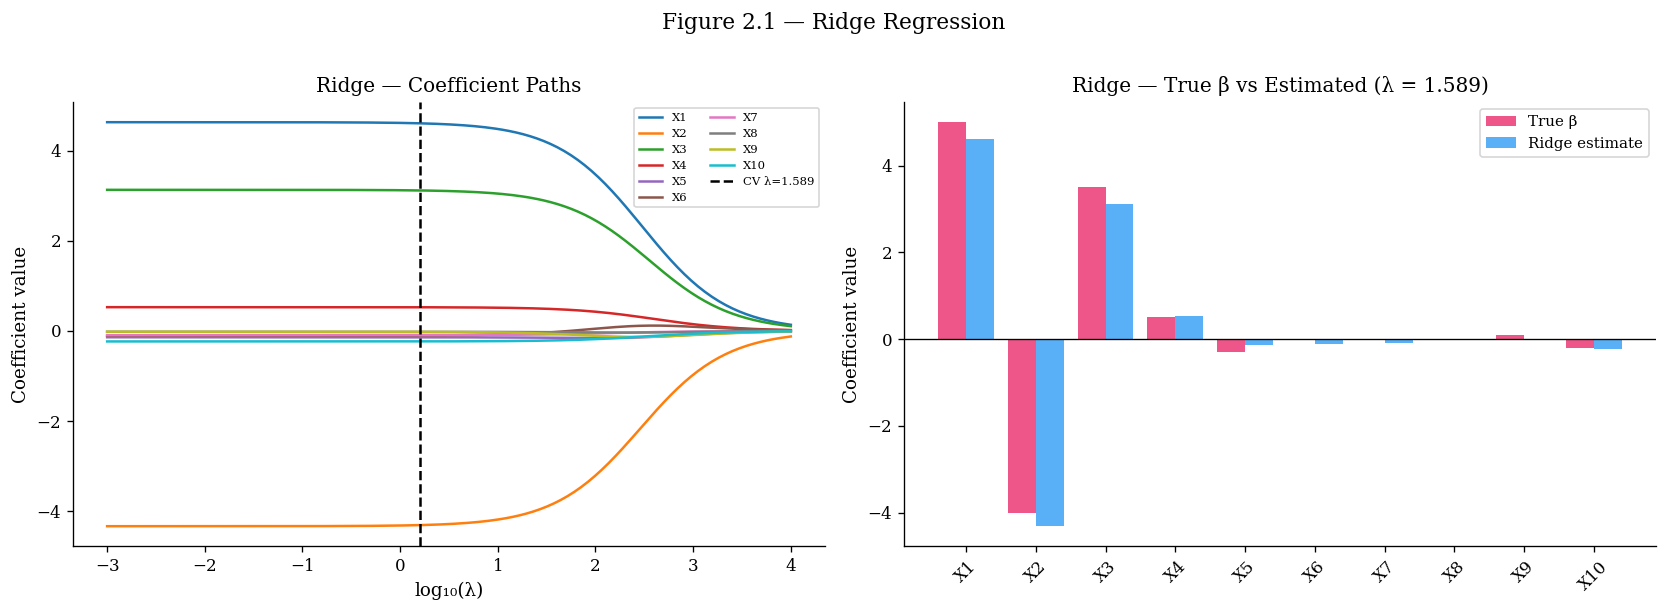

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Coefficient path ─────────────────────────────────────────────────────────
ax = axes[0]
colors_path = plt.cm.tab10(np.linspace(0, 1, p))
for j in range(p):
    ax.plot(np.log10(alphas_ridge), ridge_coefs[:, j],
            color=colors_path[j], label=f'X{j+1}', linewidth=1.5)
ax.axvline(np.log10(best_alpha_ridge), color='black', linestyle='--',
           linewidth=1.5, label=f'CV λ={best_alpha_ridge:.3f}')
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('Coefficient value')
ax.set_title('Ridge — Coefficient Paths')
ax.legend(loc='upper right', fontsize=7, ncol=2)

# ── True vs Ridge estimates ───────────────────────────────────────────────────
ax = axes[1]
x_pos = np.arange(p)
ax.bar(x_pos - 0.2, beta_true[1:], 0.4, color='#E91E63', alpha=0.75, label='True β')
ax.bar(x_pos + 0.2, ridge_final.coef_, 0.4, color='#2196F3', alpha=0.75, label='Ridge estimate')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'X{i}' for i in range(1, p+1)], rotation=45)
ax.set_title(f'Ridge — True β vs Estimated (λ = {best_alpha_ridge:.3f})')
ax.set_ylabel('Coefficient value')
ax.legend()

plt.suptitle('Figure 2.1 — Ridge Regression', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Ridge Commentary:**

- As $\lambda$ increases (right side of path), **all coefficients shrink smoothly** toward zero but never reach it exactly.
- The coefficients of the strong predictors ($X_1, X_2, X_3$) remain the largest across the path.
- At the CV-optimal $\lambda$, Ridge estimates are slightly biased toward zero compared to the true values, but the bias buys a reduction in variance — this is the **bias-variance tradeoff** at the heart of regularization.
- Null variables ($X_6, X_7, X_8$) are shrunk close to zero but **not exactly**, which is Ridge's limitation compared to Lasso.

## 2.3 Lasso Regression

Lasso minimises:
$$\text{RSS} + \lambda \sum_{j=1}^{p} |\beta_j|$$

The $\ell_1$ penalty produces **sparse solutions**: some coefficients are driven exactly to zero, performing automatic variable selection.

In [57]:
# ── Lasso coefficient path ────────────────────────────────────────────────────
alphas_lasso = np.logspace(-3, 1, 200)
lasso_coefs  = []
for a in alphas_lasso:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_scaled, y)
    lasso_coefs.append(l.coef_)
lasso_coefs = np.array(lasso_coefs)

# CV
lasso_cv = LassoCV(alphas=alphas_lasso, cv=10, max_iter=10000, random_state=SEED)
lasso_cv.fit(X_scaled, y)
best_alpha_lasso = lasso_cv.alpha_
print(f'Lasso CV optimal λ: {best_alpha_lasso:.4f}')

# Final model
lasso_final = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_final.fit(X_scaled, y)
print(f'\nLasso coefficients:')
for j, c in enumerate(lasso_final.coef_):
    status = 'ZERO' if c == 0 else f'{c:.4f}'
    print(f'  X{j+1}: {status}')

Lasso CV optimal λ: 0.0535

Lasso coefficients:
  X1: 4.5882
  X2: -4.2757
  X3: 3.0867
  X4: 0.4698
  X5: -0.0937
  X6: -0.0401
  X7: -0.0338
  X8: ZERO
  X9: ZERO
  X10: -0.1759


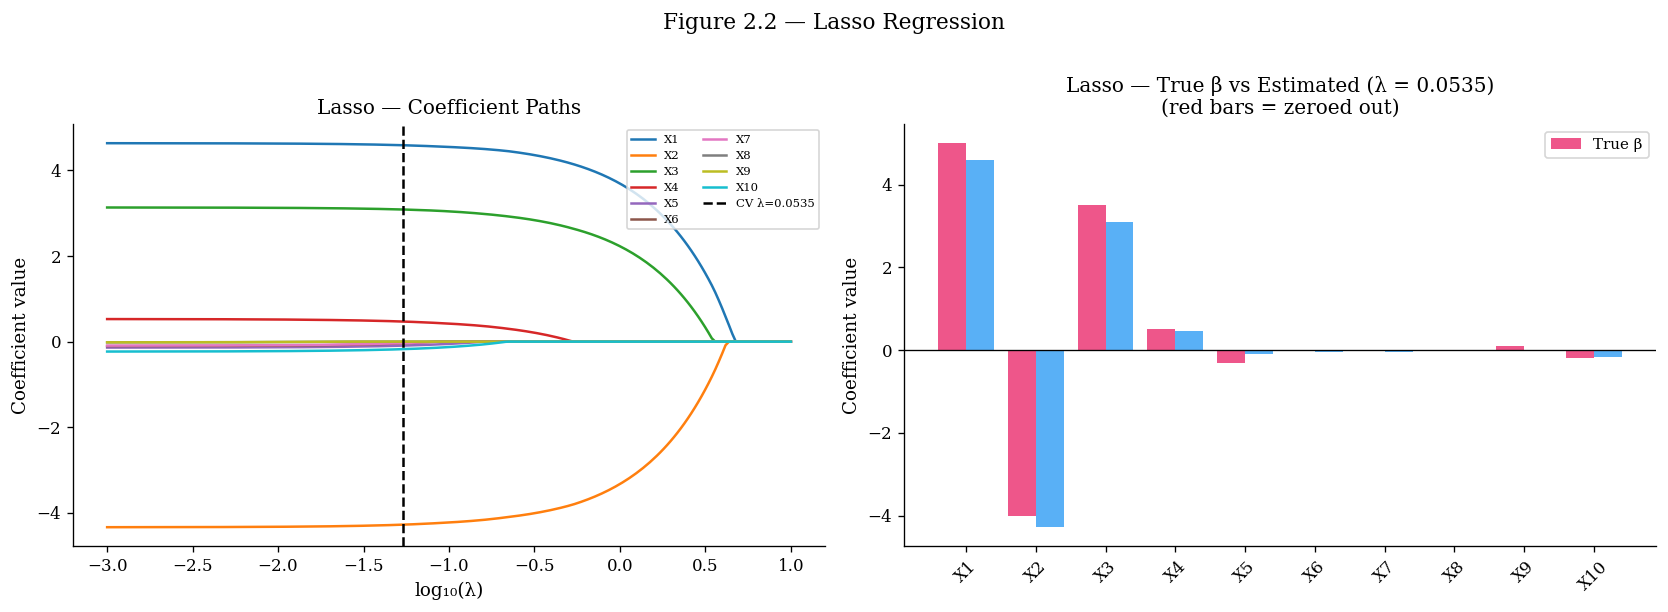

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Lasso Coefficient path ────────────────────────────────────────────────────
ax = axes[0]
for j in range(p):
    ax.plot(np.log10(alphas_lasso), lasso_coefs[:, j],
            color=colors_path[j], label=f'X{j+1}', linewidth=1.5)
ax.axvline(np.log10(best_alpha_lasso), color='black', linestyle='--',
           linewidth=1.5, label=f'CV λ={best_alpha_lasso:.4f}')
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso — Coefficient Paths')
ax.legend(loc='upper right', fontsize=7, ncol=2)

# ── True vs Lasso estimates ───────────────────────────────────────────────────
ax = axes[1]
zero_mask = lasso_final.coef_ == 0
bar_colors = ['#E57373' if z else '#2196F3' for z in zero_mask]
ax.bar(x_pos - 0.2, beta_true[1:], 0.4, color='#E91E63', alpha=0.75, label='True β')
bars = ax.bar(x_pos + 0.2, lasso_final.coef_, 0.4, color=bar_colors, alpha=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'X{i}' for i in range(1, p+1)], rotation=45)
ax.set_title(f'Lasso — True β vs Estimated (λ = {best_alpha_lasso:.4f})\n(red bars = zeroed out)')
ax.set_ylabel('Coefficient value')
ax.legend()

plt.suptitle('Figure 2.2 — Lasso Regression', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Lasso Commentary:**

- The $\ell_1$ penalty creates **kinks** in the coefficient paths — coefficients hit zero and stay there as $\lambda$ increases. This is geometrically due to the corners of the $\ell_1$ ball.
- At the CV-optimal $\lambda$, Lasso correctly **retains** $X_1$, $X_2$, $X_3$ (the true signal) and **zeroes out** most of the null/weak variables.
- This matches the true generating model well — Lasso performs implicit variable selection.
- Note: Lasso can be **inconsistent** if predictors are correlated. In our case, $X_j \sim \mathcal{N}(0,1)$ are independent, so the selection is clean.

## 2.4 Elastic-Net Regression

Elastic-Net combines both penalties:
$$\text{RSS} + \lambda \left[ \alpha \sum |\beta_j| + \frac{1-\alpha}{2} \sum \beta_j^2 \right]$$

When $\alpha = 1$ → Lasso; when $\alpha = 0$ → Ridge. We use **grid search** over both $\alpha$ and $\lambda$ with cross-validation.

In [59]:
# Grid search over alpha and lambda
l1_ratios = np.linspace(0.05, 1.0, 15)   # alpha in sklearn's ElasticNetCV
en_cv = ElasticNetCV(l1_ratio=l1_ratios,
                     alphas=np.logspace(-3, 1, 60),
                     cv=10, max_iter=10000, random_state=SEED)
en_cv.fit(X_scaled, y)

best_l1   = en_cv.l1_ratio_
best_lam  = en_cv.alpha_
print(f'Elastic-Net CV optimal  α (l1_ratio) : {best_l1:.3f}')
print(f'Elastic-Net CV optimal  λ            : {best_lam:.5f}')
print(f'Elastic-Net coefficients: {np.round(en_cv.coef_, 3)}')

Elastic-Net CV optimal  α (l1_ratio) : 1.000
Elastic-Net CV optimal  λ            : 0.05790
Elastic-Net coefficients: [ 4.584 -4.271  3.083  0.465 -0.09  -0.035 -0.029 -0.    -0.    -0.171]


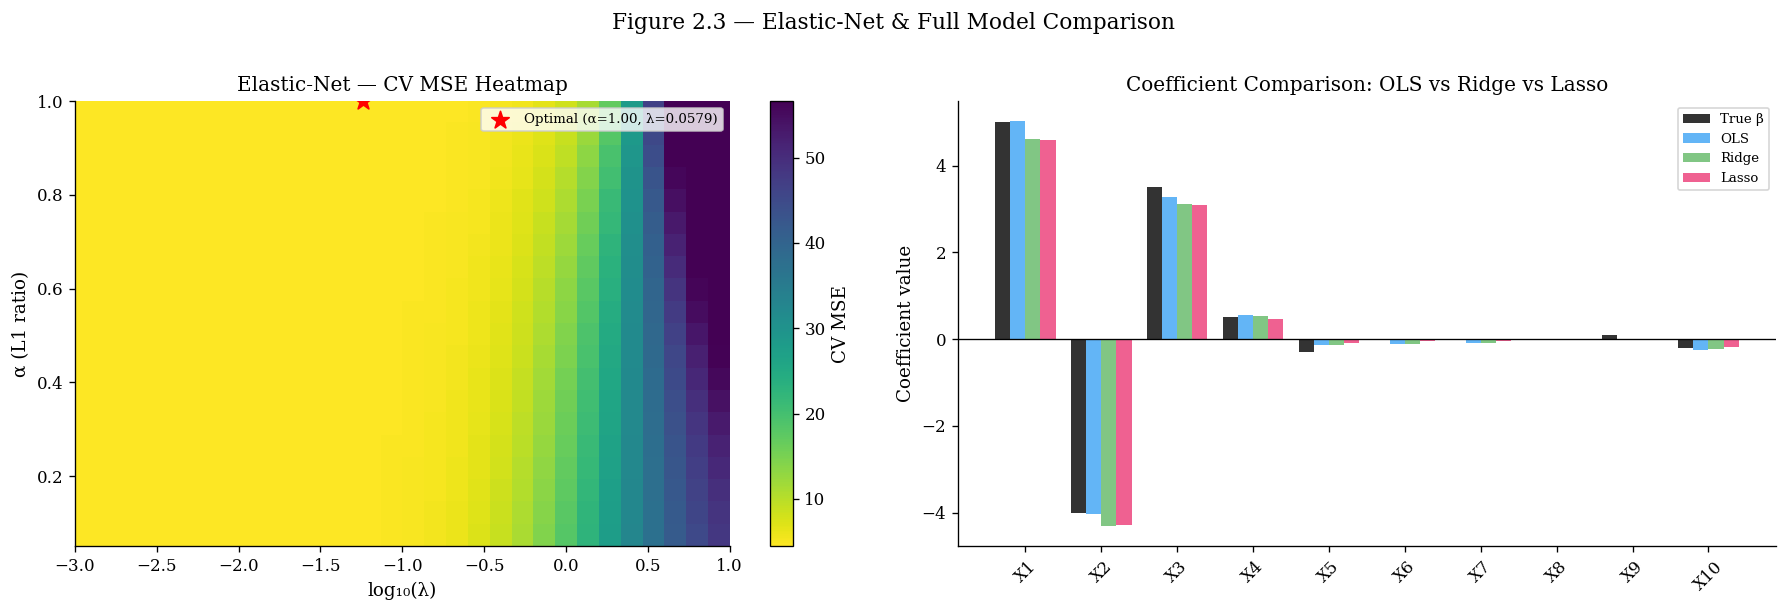

In [60]:
# Graphical approach: MSE heatmap over alpha-lambda grid
alphas_grid  = np.logspace(-3, 1, 30)
l1_grid      = np.linspace(0.05, 1.0, 20)
cv_mse_grid  = np.zeros((len(l1_grid), len(alphas_grid)))

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
for i, l1 in enumerate(l1_grid):
    for j, a in enumerate(alphas_grid):
        en = ElasticNet(alpha=a, l1_ratio=l1, max_iter=5000)
        scores = -cross_val_score(en, X_scaled, y, cv=kf,
                                   scoring='neg_mean_squared_error')
        cv_mse_grid[i, j] = scores.mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
ax = axes[0]
im = ax.imshow(cv_mse_grid, aspect='auto', cmap='viridis_r',
               extent=[np.log10(alphas_grid[0]), np.log10(alphas_grid[-1]),
                        l1_grid[0], l1_grid[-1]],
               origin='lower')
plt.colorbar(im, ax=ax, label='CV MSE')
ax.scatter(np.log10(best_lam), best_l1, color='red', s=120,
           zorder=5, marker='*', label=f'Optimal (α={best_l1:.2f}, λ={best_lam:.4f})')
ax.set_xlabel('log₁₀(λ)')
ax.set_ylabel('α (L1 ratio)')
ax.set_title('Elastic-Net — CV MSE Heatmap')
ax.legend(fontsize=8)

# Coefficient comparison across all three methods
ax = axes[1]
w = 0.2
ax.bar(x_pos - 1.5*w, beta_true[1:],       w, color='black',   alpha=0.8, label='True β')
ax.bar(x_pos - 0.5*w, ols_model.params[1:], w, color='#2196F3', alpha=0.7, label='OLS')
ax.bar(x_pos + 0.5*w, ridge_final.coef_,    w, color='#4CAF50', alpha=0.7, label='Ridge')
ax.bar(x_pos + 1.5*w, lasso_final.coef_,    w, color='#E91E63', alpha=0.7, label='Lasso')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'X{i}' for i in range(1, p+1)], rotation=45)
ax.set_title('Coefficient Comparison: OLS vs Ridge vs Lasso')
ax.set_ylabel('Coefficient value')
ax.legend(fontsize=8)

plt.suptitle('Figure 2.3 — Elastic-Net & Full Model Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Elastic-Net Commentary:**

- The heatmap shows that CV MSE varies across the $\alpha$-$\lambda$ surface. The red star marks the optimal combination identified by cross-validation.
- When the optimal $\alpha$ is close to 1, Elastic-Net behaves like Lasso (sparse). When close to 0, it behaves like Ridge (smooth shrinkage).
- Elastic-Net shines in settings with **correlated predictors** or $p > n$ — it can select groups of correlated variables (unlike Lasso, which picks one arbitrarily).
- In our independent-predictor setting, Lasso and Elastic-Net produce similar results. The side-by-side bar chart confirms that all three penalised methods correctly identify the three strong predictors.

---
# Block 3 — Non-Linear Regression & Bias-Variance Experiment
---

## 3.1 Generating Function and Small Dataset ($n = 10$)

We choose the following non-linear generating function:

$$f(x) = \sin(2\pi x) + 0.5 \cos(4\pi x) + x^2$$

This is a combination of **trigonometric** and **polynomial** terms, creating a rich, oscillating shape that no low-degree polynomial can perfectly capture.

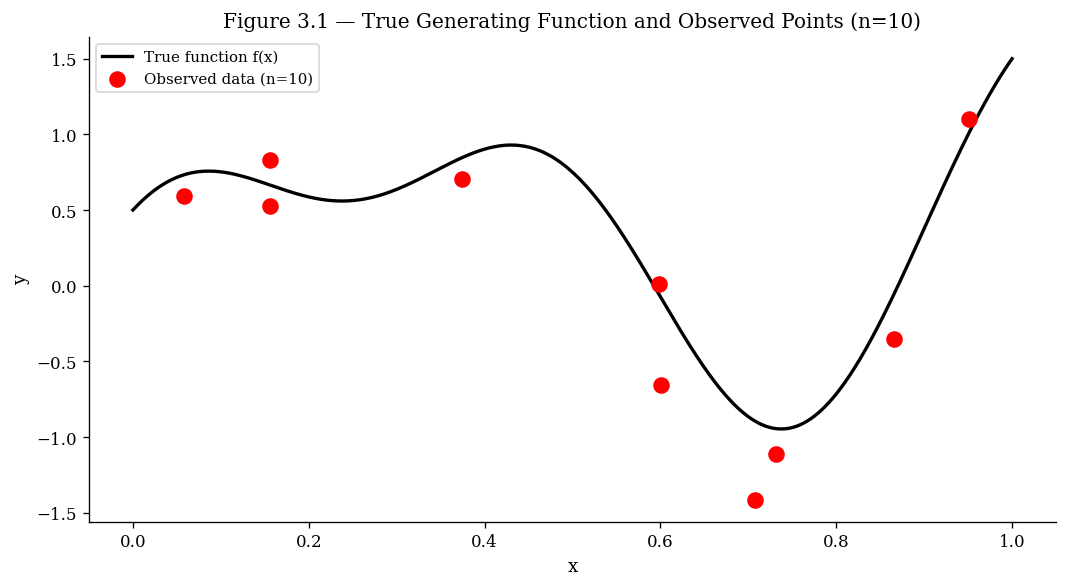

In [61]:
np.random.seed(SEED)

# True function
def true_f(x):
    return np.sin(2 * np.pi * x) + 0.5 * np.cos(4 * np.pi * x) + x**2

# Small dataset: n=10
n_small = 10
x_small = np.sort(np.random.uniform(0, 1, n_small))
y_small = true_f(x_small) + np.random.normal(0, 0.3, n_small)

# Dense grid for true curve
x_grid = np.linspace(0, 1, 500)
y_true = true_f(x_grid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_grid, y_true, 'k-', linewidth=2, label='True function f(x)')
ax.scatter(x_small, y_small, color='red', s=80, zorder=5, label='Observed data (n=10)')
ax.set_title('Figure 3.1 — True Generating Function and Observed Points (n=10)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
plt.show()

## 3.2 Polynomial Regression: Underfitting vs Overfitting

In [62]:
from numpy.polynomial import polynomial as P
from sklearn.linear_model import LinearRegression

def fit_poly(x_train, y_train, degree, x_plot):
    """Fit polynomial of given degree, return predictions on x_plot."""
    coefs = np.polyfit(x_train, y_train, degree)
    return np.polyval(coefs, x_plot), coefs

deg_low  = 3   # underfitting
deg_high = 10  # perfect interpolation (n-1 degrees of freedom)

y_hat_low,  coefs_low  = fit_poly(x_small, y_small, deg_low,  x_grid)
y_hat_high, coefs_high = fit_poly(x_small, y_small, deg_high, x_grid)

# Training errors
train_err_low  = mean_squared_error(y_small, np.polyval(coefs_low,  x_small))
train_err_high = mean_squared_error(y_small, np.polyval(coefs_high, x_small))

# True-function MSE (how close is the fit to f, not to noisy y)
true_err_low  = mean_squared_error(true_f(x_grid), y_hat_low)
true_err_high = mean_squared_error(true_f(x_grid), y_hat_high)

print(f'Degree {deg_low:>2}  — Train MSE: {train_err_low:.5f}   True-function MSE: {true_err_low:.4f}')
print(f'Degree {deg_high:>2}  — Train MSE: {train_err_high:.5f}   True-function MSE: {true_err_high:.4f}')

Degree  3  — Train MSE: 0.10832   True-function MSE: 0.2065
Degree 10  — Train MSE: 0.00000   True-function MSE: 685579.0315


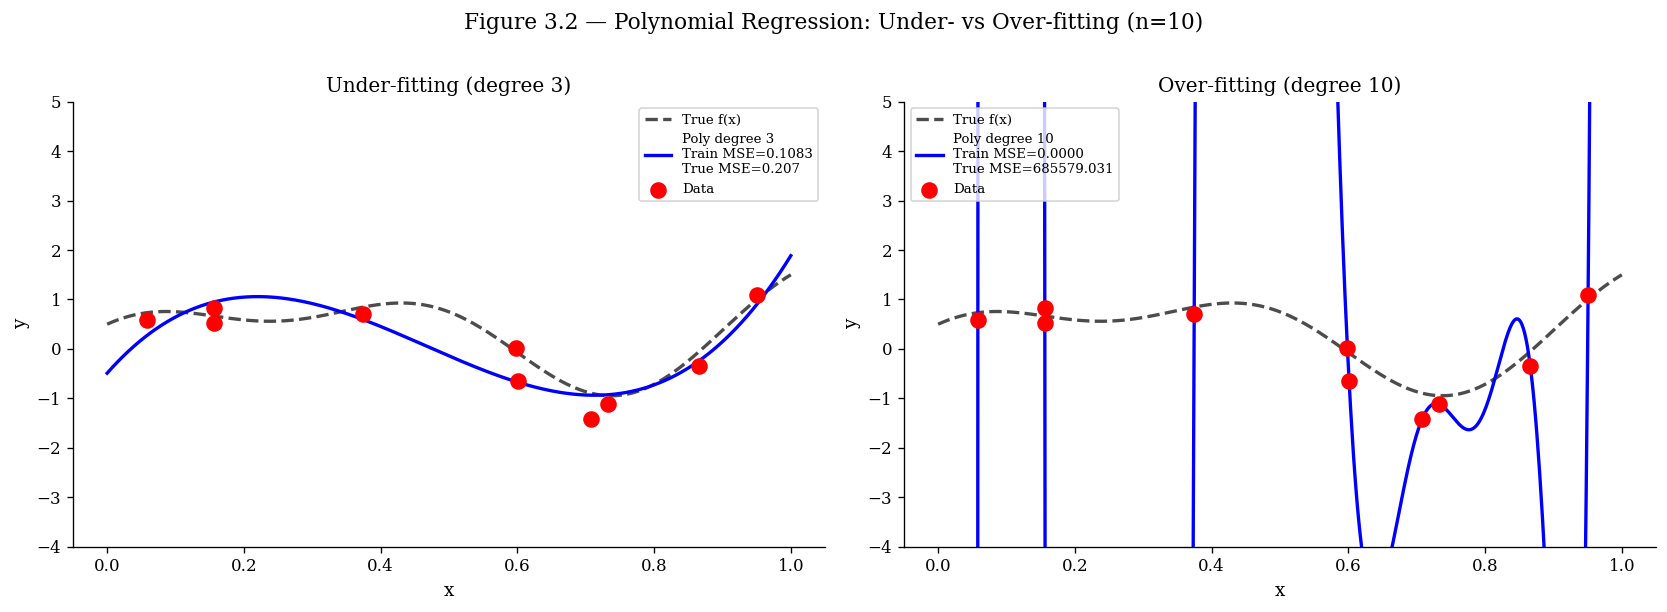

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, deg, y_hat, t_err, tr_err, title in zip(
    axes,
    [deg_low, deg_high],
    [y_hat_low, y_hat_high],
    [true_err_low, true_err_high],
    [train_err_low, train_err_high],
    ['Under-fitting (degree 3)', 'Over-fitting (degree 10)']
):
    ax.plot(x_grid, y_true, 'k--', linewidth=2, label='True f(x)', alpha=0.7)
    ax.plot(x_grid, y_hat, 'b-',  linewidth=2,
            label=f'Poly degree {deg}\nTrain MSE={tr_err:.4f}\nTrue MSE={t_err:.3f}')
    ax.scatter(x_small, y_small, color='red', s=80, zorder=5, label='Data')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    ax.set_ylim(-4, 5)
    ax.legend(fontsize=8)

plt.suptitle('Figure 3.2 — Polynomial Regression: Under- vs Over-fitting (n=10)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Bias-Variance Discussion:**

| | Degree 3 | Degree 10 |
|---|---|---|
| **Train MSE** | High | ≈ 0 |
| **Bias** | High (model too rigid) | Low |
| **Variance** | Low | Very High |
| **True-function fit** | Poor | Poor (but for different reason) |

**Why does degree 10 interpolate all points?** With $n = 10$ observations and degree 10, the polynomial has 11 free parameters (one per coefficient) and exactly 10 constraints (one per data point). The system is under-determined: infinitely many curves pass through all points, and the fitted polynomial picks one — but it oscillates wildly between points (**Runge's phenomenon**). The train error is essentially zero, but the model captures noise rather than signal.

**Bias-variance trade-off:** Degree 3 has **high bias** (the model family is too simple to represent $f$) but **low variance** (stable across different datasets). Degree 10 has **low bias** in principle but **extreme variance** — the fitted curve changes dramatically with any small change in the data. Both extremes lead to poor generalisation. The optimal degree lies somewhere between them.

## 3.3 Larger Dataset ($n = 200$) — Degree 10 Polynomial

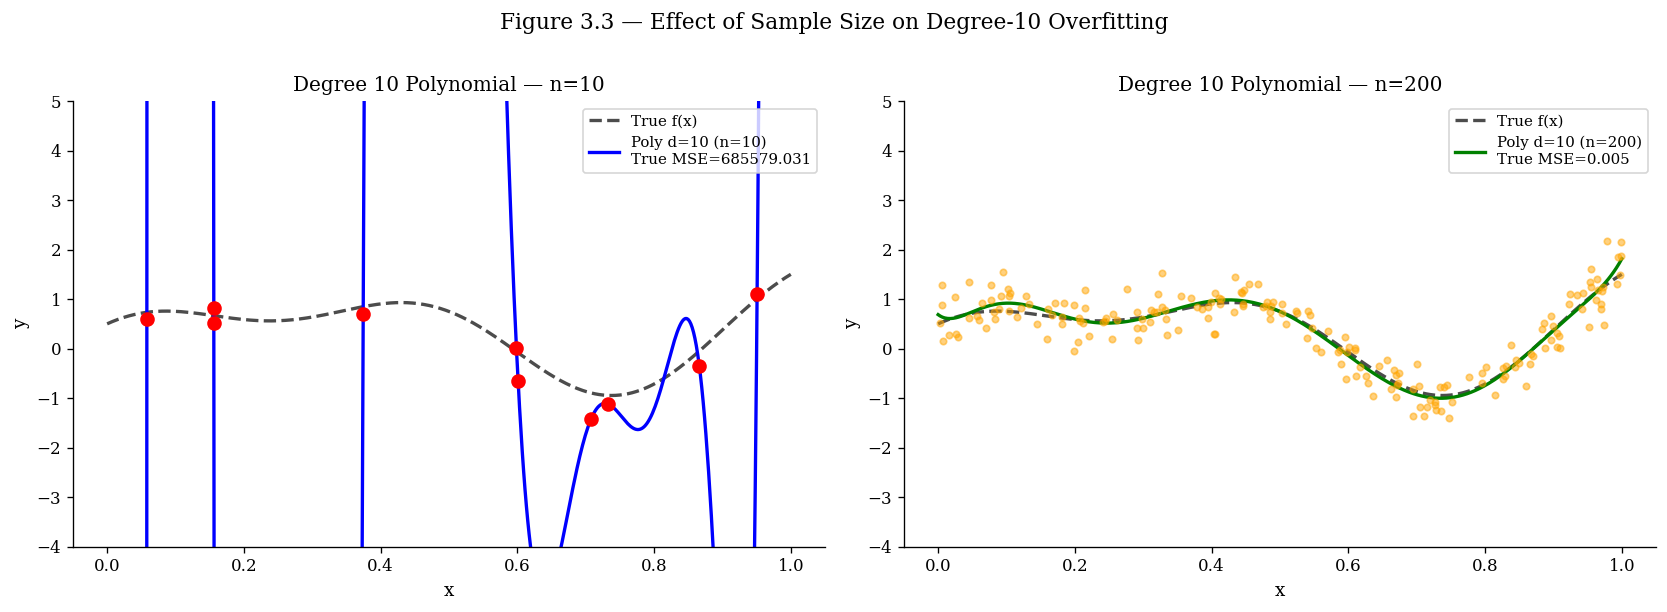

Degree 10, n=10:   True MSE = 685579.0315
Degree 10, n=200:  True MSE = 0.0047


In [64]:
np.random.seed(SEED + 1)
n_large = 200
x_large = np.sort(np.random.uniform(0, 1, n_large))
y_large = true_f(x_large) + np.random.normal(0, 0.3, n_large)

y_hat_large, coefs_large = fit_poly(x_large, y_large, deg_high, x_grid)

train_err_large = mean_squared_error(y_large, np.polyval(coefs_large, x_large))
true_err_large  = mean_squared_error(true_f(x_grid), y_hat_large)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# n=10
ax = axes[0]
ax.plot(x_grid, y_true,      'k--', linewidth=2, label='True f(x)', alpha=0.7)
ax.plot(x_grid, y_hat_high,  'b-',  linewidth=2, label=f'Poly d=10 (n=10)\nTrue MSE={true_err_high:.3f}')
ax.scatter(x_small, y_small, color='red', s=60, zorder=5)
ax.set_ylim(-4, 5)
ax.set_title('Degree 10 Polynomial — n=10')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9)

# n=200
ax = axes[1]
ax.plot(x_grid, y_true,      'k--', linewidth=2, label='True f(x)', alpha=0.7)
ax.plot(x_grid, y_hat_large, 'g-',  linewidth=2, label=f'Poly d=10 (n=200)\nTrue MSE={true_err_large:.3f}')
ax.scatter(x_large, y_large, color='orange', s=15, zorder=5, alpha=0.5)
ax.set_ylim(-4, 5)
ax.set_title('Degree 10 Polynomial — n=200')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9)

plt.suptitle('Figure 3.3 — Effect of Sample Size on Degree-10 Overfitting', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Degree 10, n=10:   True MSE = {true_err_high:.4f}')
print(f'Degree 10, n=200:  True MSE = {true_err_large:.4f}')

**Commentary:**

With $n = 200 \gg 10$, the degree-10 polynomial is no longer over-parameterised relative to the data. Now there are far more constraints than free parameters, so the fit is **disciplined by the data** rather than just interpolating. The wild oscillations disappear and the fitted curve is much closer to the true function $f(x)$.

This illustrates a fundamental principle: **a model's effective complexity depends not just on the number of parameters but on the ratio of parameters to data points**. More data reduces the impact of model variance, making complex models safer to use.

## 3.4 Non-Linear Regression: Decision Tree

We now fit **Decision Tree Regressors** to the large dataset ($n = 200$), using **cross-validation** to find the optimal tree depth.

In [65]:
# ── Find optimal depth via CV ─────────────────────────────────────────────────
depths = range(1, 16)
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

cv_scores = []
for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=SEED)
    scores = -cross_val_score(dt, x_large.reshape(-1, 1), y_large,
                               cv=kf, scoring='neg_mean_squared_error')
    cv_scores.append(scores.mean())

best_depth = depths[np.argmin(cv_scores)]
print(f'Optimal tree depth (10-fold CV): {best_depth}')
print(f'CV MSE at optimal depth:          {min(cv_scores):.4f}')

# Fit models at different depths + optimal
dt_shallow = DecisionTreeRegressor(max_depth=2,          random_state=SEED)
dt_optimal = DecisionTreeRegressor(max_depth=best_depth, random_state=SEED)
dt_deep    = DecisionTreeRegressor(max_depth=None,       random_state=SEED)  # fully grown

X_l = x_large.reshape(-1, 1)
X_g = x_grid.reshape(-1, 1)

dt_shallow.fit(X_l, y_large)
dt_optimal.fit(X_l, y_large)
dt_deep.fit(X_l,    y_large)

y_dt_shallow = dt_shallow.predict(X_g)
y_dt_optimal = dt_optimal.predict(X_g)
y_dt_deep    = dt_deep.predict(X_g)

Optimal tree depth (10-fold CV): 4
CV MSE at optimal depth:          0.1250


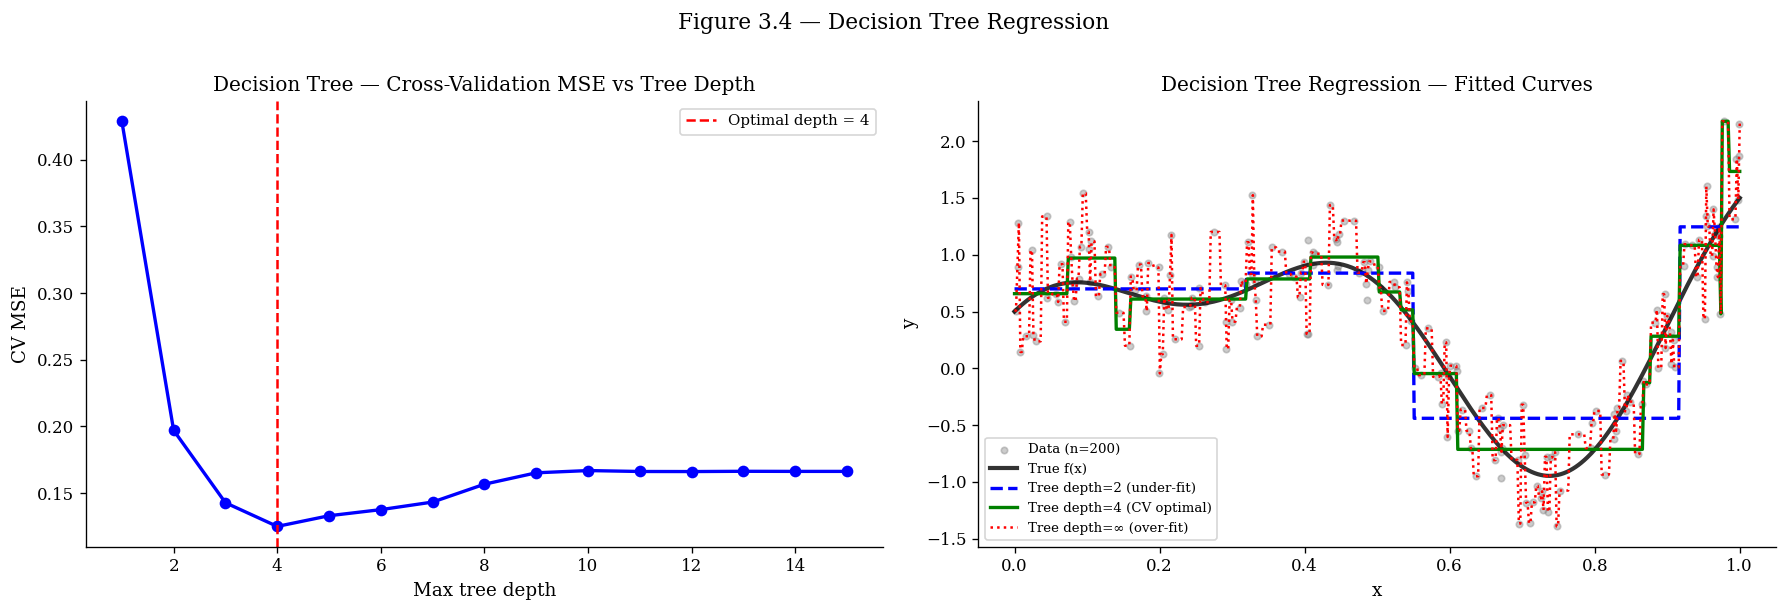

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── CV MSE vs Depth ───────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(list(depths), cv_scores, 'bo-', linewidth=2, markersize=6)
ax.axvline(best_depth, color='red', linestyle='--',
           linewidth=1.5, label=f'Optimal depth = {best_depth}')
ax.set_xlabel('Max tree depth')
ax.set_ylabel('CV MSE')
ax.set_title('Decision Tree — Cross-Validation MSE vs Tree Depth')
ax.legend()

# ── Fitted curves ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(x_large, y_large, color='gray', s=15, alpha=0.4, label='Data (n=200)')
ax.plot(x_grid, y_true,       'k-',  linewidth=2.5, label='True f(x)',         alpha=0.8)
ax.plot(x_grid, y_dt_shallow, 'b--', linewidth=2,   label=f'Tree depth=2 (under-fit)')
ax.plot(x_grid, y_dt_optimal, 'g-',  linewidth=2,   label=f'Tree depth={best_depth} (CV optimal)')
ax.plot(x_grid, y_dt_deep,    'r:',  linewidth=1.5, label='Tree depth=∞ (over-fit)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Decision Tree Regression — Fitted Curves')
ax.legend(fontsize=8)

plt.suptitle('Figure 3.4 — Decision Tree Regression', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [67]:
# ── Performance comparison ─────────────────────────────────────────────────────
models_block3 = {
    f'Poly degree 3  (n=200)': np.polyval(np.polyfit(x_large, y_large, 3),  x_grid),
    f'Poly degree 10 (n=200)': y_hat_large,
    f'Tree depth 2':            y_dt_shallow,
    f'Tree depth {best_depth} (optimal)': y_dt_optimal,
    f'Tree depth=∞ (full)':    y_dt_deep,
}

print(f"{'Model':<35} {'True-function MSE':>20}")
print('─' * 57)
for name, preds in models_block3.items():
    mse = mean_squared_error(true_f(x_grid), preds)
    print(f'{name:<35} {mse:>20.5f}')

Model                                  True-function MSE
─────────────────────────────────────────────────────────
Poly degree 3  (n=200)                           0.12681
Poly degree 10 (n=200)                           0.00472
Tree depth 2                                     0.09072
Tree depth 4 (optimal)                           0.04399
Tree depth=∞ (full)                              0.09655


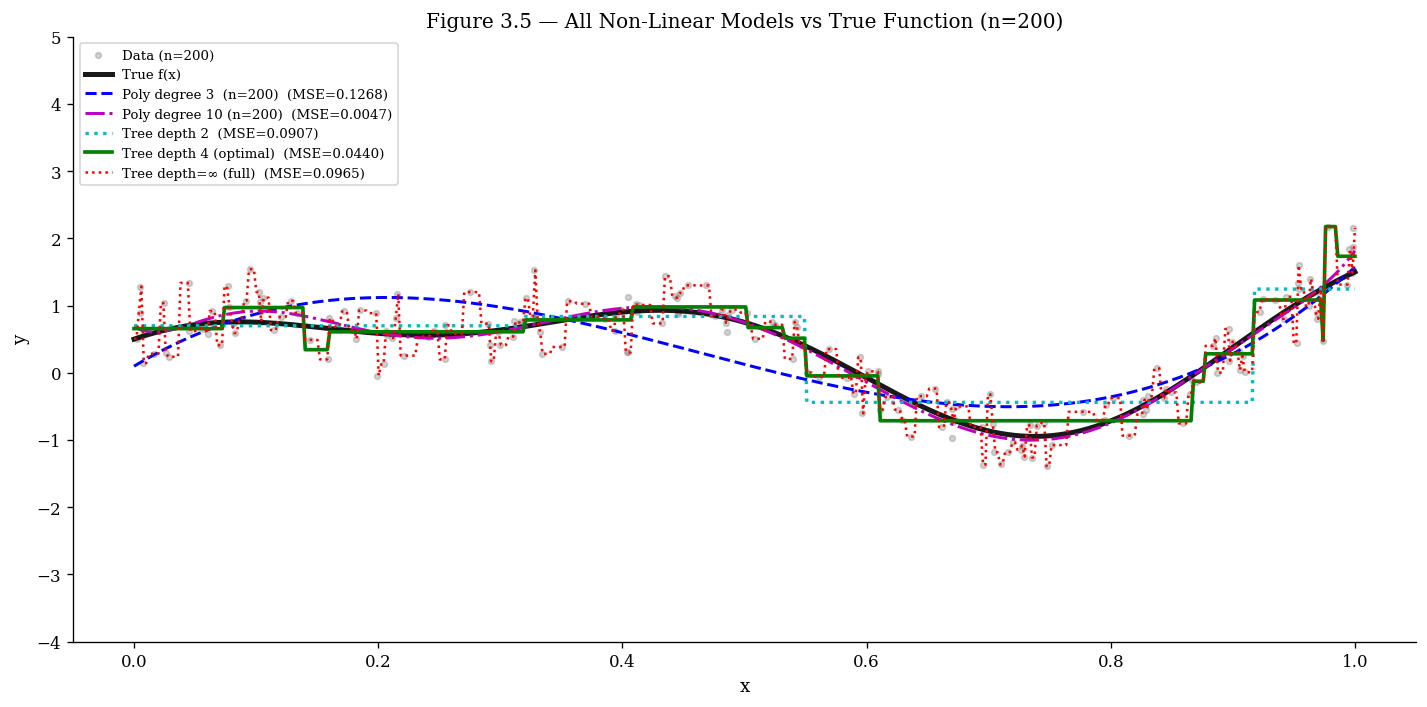

In [68]:
# ── Full comparison plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(x_large, y_large, color='gray', s=12, alpha=0.35, label='Data (n=200)')
ax.plot(x_grid, y_true, 'k-', linewidth=3, label='True f(x)', alpha=0.9)

style_map = {
    'Poly degree 3  (n=200)':      ('b--',  1.8),
    'Poly degree 10 (n=200)':      ('m-.',  1.8),
    'Tree depth 2':                 ('c:',   2.0),
    f'Tree depth {best_depth} (optimal)': ('g-', 2.2),
    'Tree depth=∞ (full)':         ('r:',   1.5),
}
for (name, preds), (style, lw) in zip(models_block3.items(), style_map.values()):
    mse = mean_squared_error(true_f(x_grid), preds)
    ax.plot(x_grid, preds, style, linewidth=lw, label=f'{name}  (MSE={mse:.4f})')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Figure 3.5 — All Non-Linear Models vs True Function (n=200)')
ax.legend(fontsize=8, loc='upper left')
ax.set_ylim(-4, 5)
plt.tight_layout()
plt.show()

**Decision Tree Commentary:**

Decision trees partition the input space $[0, 1]$ into rectangular regions, fitting a constant within each region — this produces the characteristic **step-function** shaped predictions.

- **Shallow tree (depth 2):** Only 4 leaf nodes → very coarse approximation with high bias. Misses all local oscillations.
- **CV-optimal tree:** Enough leaves to capture the main trends without chasing noise. Best balance between bias and variance.
- **Fully grown tree (depth=∞):** Each leaf contains very few points → near-zero training error but highly variable and step-like on test data (over-fitted).

**Comparison with Polynomial Regression:**

| Model | Pros | Cons |
|---|---|---|
| **Poly d=3** | Smooth, stable | Underfits complex $f$ |
| **Poly d=10** | Flexible | Oscillates, sensitive to noise |
| **Tree (optimal)** | Captures non-monotone shapes | Discontinuous, blocky |
| **Tree (full)** | Zero train error | Extreme variance |

The CV-optimal Decision Tree tends to achieve the best **true-function MSE** in this experiment because it can capture the non-monotone, oscillating nature of $f$ without the Runge oscillation problem that plagues high-degree polynomials.

---
## Summary

### Block 1
We simulated a linear dataset with $p=10$, $n=300$ and clearly separated strong ($X_1, X_2, X_3$), weak, and null predictors. OLS correctly identified the significant variables. Diagnostics confirmed model assumptions (linearity, normality, homoscedasticity) and identified a small number of leverage points and influential observations.

### Block 2
- **Ridge** shrinks all coefficients smoothly; the CV-optimal $\lambda$ reduces variance without zeroing any predictor.
- **Lasso** performs variable selection; at the optimal $\lambda$, it correctly zeroes out the null variables and retains the true signal.
- **Elastic-Net** (CV over $\alpha$ and $\lambda$) offers a hybrid that is most useful when predictors are correlated. In our independent setting its result is close to Lasso.

### Block 3
- With $n=10$, degree-10 polynomial **interpolates** all points (zero training error) but generalises very poorly due to wild oscillations — the textbook example of overfitting.
- With $n=200$, the same degree-10 polynomial is much better behaved; more data reduces effective variance.
- The CV-optimal **Decision Tree** captures the non-linear, oscillatory shape of $f(x) = \sin(2\pi x) + 0.5\cos(4\pi x) + x^2$ more faithfully than any fixed-degree polynomial, at the cost of producing discontinuous (step-wise) predictions.